In [1]:
import pandas as pd

df = pd.read_csv("/content/loan_approval_dataset.csv")

print(df.head())
print(df.info())
print(df.describe())
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns)

   loan_id   no_of_dependents      education  self_employed   income_annum  \
0        1                  2       Graduate             No        9600000   
1        2                  0   Not Graduate            Yes        4100000   
2        3                  3       Graduate             No        9100000   
3        4                  3       Graduate             No        8200000   
4        5                  5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_asset_value  \
0                  1760000

In [2]:
df=df.drop('loan_id', axis=1)
print(df.head())

   no_of_dependents      education self_employed  income_annum  loan_amount  \
0                 2       Graduate            No       9600000     29900000   
1                 0   Not Graduate           Yes       4100000     12200000   
2                 3       Graduate            No       9100000     29700000   
3                 3       Graduate            No       8200000     30700000   
4                 5   Not Graduate           Yes       9800000     24200000   

   loan_term  cibil_score  residential_assets_value  commercial_assets_value  \
0         12          778                   2400000                 17600000   
1          8          417                   2700000                  2200000   
2         20          506                   7100000                  4500000   
3          8          467                  18200000                  3300000   
4         20          382                  12400000                  8200000   

   luxury_assets_value  bank_asset_value loa

In [3]:
print(df['education'].unique())
print(df['self_employed'].unique())
print(df['loan_status'].unique())

[' Graduate' ' Not Graduate']
[' No' ' Yes']
[' Approved' ' Rejected']


In [4]:
df['education'] = df['education'].str.strip()
df['self_employed'] = df['self_employed'].str.strip()
df['loan_status'] = df['loan_status'].str.strip()

In [5]:
print(df['education'].unique())

['Graduate' 'Not Graduate']


In [6]:
df['education'] = df['education'].map({'Graduate': 1, 'Not Graduate': 0})
df['self_employed'] = df['self_employed'].map({'Yes': 1, 'No': 0})
df['loan_status'] = df['loan_status'].map({'Approved': 1, 'Rejected': 0})

In [7]:
print(df.isnull().sum())

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [10]:
y_pred = lr.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7985948477751756
Confusion Matrix:
 [[194 124]
 [ 48 488]]
Report:
               precision    recall  f1-score   support

           0       0.80      0.61      0.69       318
           1       0.80      0.91      0.85       536

    accuracy                           0.80       854
   macro avg       0.80      0.76      0.77       854
weighted avg       0.80      0.80      0.79       854



In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 0.9754098360655737


In [13]:
print("LR Train:", lr.score(X_train, y_train))
print("LR Test:", lr.score(X_test, y_test))

print("RF Train:", rf.score(X_train, y_train))
print("RF Test:", rf.score(X_test, y_test))

LR Train: 0.7950219619326501
LR Test: 0.7985948477751756
RF Train: 1.0
RF Test: 0.9754098360655737


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf.fit(X_train, y_train)

print("RF Train:", rf.score(X_train, y_train))
print("RF Test:", rf.score(X_test, y_test))

RF Train: 0.9941434846266471
RF Test: 0.9730679156908665


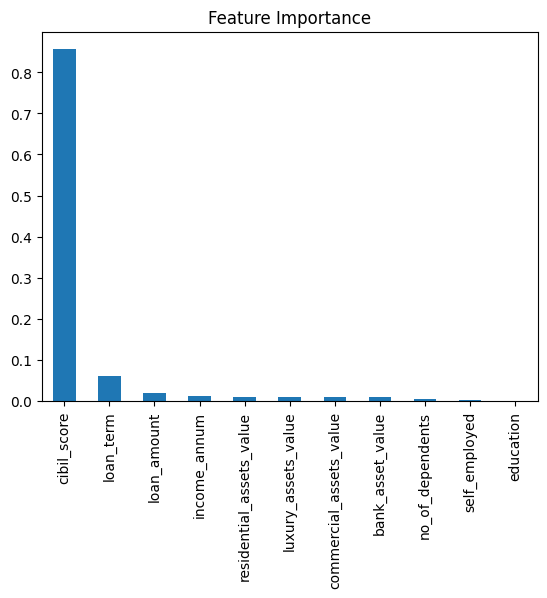

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar')

plt.title("Feature Importance")
plt.show()

In [16]:
!pip install shap

In [17]:
import shap

explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test)

 90%|==================  | 1529/1708 [00:15<00:01]       

In [18]:
shap_values[1]

.values =
array([[-5.75345568e-04,  5.75345471e-04],
       [ 2.44861971e-04, -2.44861921e-04],
       [-6.32260434e-04,  6.32260322e-04],
       [-2.89081283e-03,  2.89081200e-03],
       [ 5.46537580e-03, -5.46537569e-03],
       [ 7.98962671e-03, -7.98962789e-03],
       [-3.71023605e-01,  3.71023603e-01],
       [-6.05862662e-03,  6.05862605e-03],
       [-3.59292567e-03,  3.59292552e-03],
       [ 3.28346571e-05, -3.28352420e-05],
       [-2.11819395e-03,  2.11819338e-03]])

.base_values =
array([0.38366908, 0.61633092])

.data =
array([       2,        1,        0,  5900000, 14000000,        8,
            599,  4700000,  9500000, 17800000,  6700000])

In [19]:
print(type(shap_values))
print(shap_values.shape)

<class 'shap._explanation.Explanation'>
(854, 11, 2)


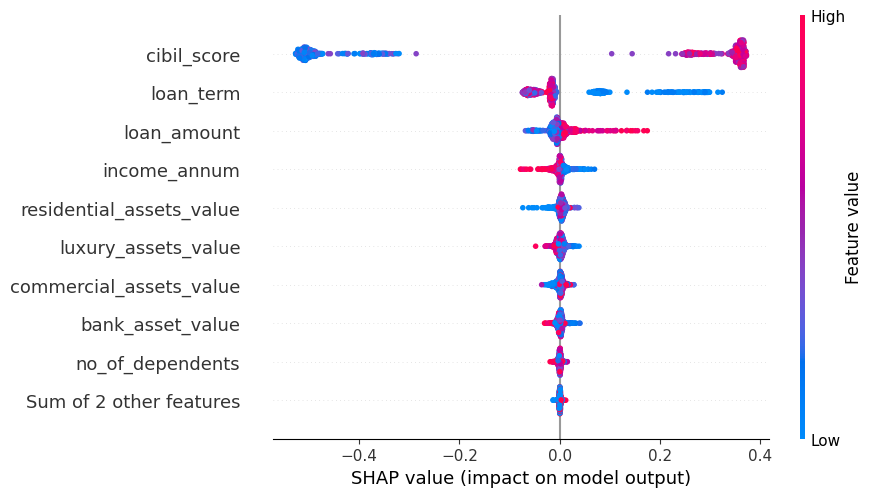

In [20]:
shap.plots.beeswarm(shap_values[:, :, 1])

In [21]:
import joblib

joblib.dump(rf, "loan_model.pkl")

['loan_model.pkl']

In [22]:
from google.colab import files

files.download("loan_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>